In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb

# Hyperparameters
mb_size = 64
Z_dim = 100
y_dim = 10           # Labels: Number of classes (0-9)
h_dim = 128
lr = 1e-3

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Conditional Generator
class Generator(nn.Module):
    def __init__(self, z_dim, y_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim + y_dim, h_dim) # Input is noise + class label
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z, c):  # z is the input noise vector, c is the class label
        x = torch.cat([z, c], dim=1) # Concatenate noise and class label
        h = F.relu(self.fc1(x)) # Hidden layer with ReLU activation
        out = torch.sigmoid(self.fc2(h)) # Output generated image using sigmoid activation
        return out

# Conditional Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, y_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim + y_dim, h_dim)  # Input is image + class label
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, c): # x is the input image, c is the class label
        x = torch.cat([x, c], dim=1) # Concatenate image and class label
        h = F.relu(self.fc1(x)) # Hidden layer with ReLU activation
        out = torch.sigmoid(self.fc2(h)) # Output probability of the input image being real
        return out

# Training Function
def cGANTraining(G, D, loss_fn, train_loader):
    G.train()
    D.train()
    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        # Prepare real data
        X_real = X_real.float().to(device)
        labels = F.one_hot(labels, num_classes=y_dim).float().to(device) # use one-hot encoded labels

        # Sample noise
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)

        # ==== Train Discriminator ====
        G_sample = G(z, labels)
        D_real = D(X_real, labels)
        D_fake = D(G_sample.detach(), labels)

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ==== Train Generator ====
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z, labels)
        D_fake = D(G_sample, labels)

        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

    # Logging
    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    wandb.log({
        "D_loss_real": D_loss_real_avg,
        "D_loss_fake": D_loss_fake_avg,
        "D_loss": D_loss_avg,
        "G_loss": G_loss_avg
    })

    return G, D, G_loss_avg, D_loss_avg

# Save image samples
def save_sample(G, epoch, mb_size, Z_dim, label):
    out_dir = "out_cGAN"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        labels = torch.full((mb_size,), label, dtype=torch.long).to(device)
        labels_one_hot = F.one_hot(labels, num_classes=y_dim).float().to(device) # Choose label to generate
        samples = G(z, labels_one_hot).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(f'{out_dir}'):
        os.makedirs(f'{out_dir}')

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)

###################### Main ########################
wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Models
G = Generator(Z_dim, y_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, y_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Loss Function (BCE with logits version is often better)
def loss_fn(preds, targets):
    return F.binary_cross_entropy(preds, targets)

if wandb_log:
    wandb.init(project="cgan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "y_dim": y_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')
save_dir = 'checkpoints_cgan'
os.makedirs(save_dir, exist_ok=True)

# Training loop
epochs = 100
target_label = 3  # <-- change this number to generate different digits

for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, loss_fn, train_loader)

    print(f'epoch {epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim, target_label)


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 541kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.87MB/s]


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: daehen-4 (ertveh-4-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


100%|██████████| 938/938 [00:24<00:00, 37.71it/s]


epoch 0; D_loss: 0.0764; G_loss: 5.6430
Saved Best Models at epoch 0 | G_loss: 5.6430


...

epoch 97; D_loss: 0.8645; G_loss: 1.6597


100%|██████████| 938/938 [00:22<00:00, 41.36it/s]


epoch 98; D_loss: 0.8658; G_loss: 1.6604


100%|██████████| 938/938 [00:23<00:00, 39.82it/s]


epoch 99; D_loss: 0.8640; G_loss: 1.6608


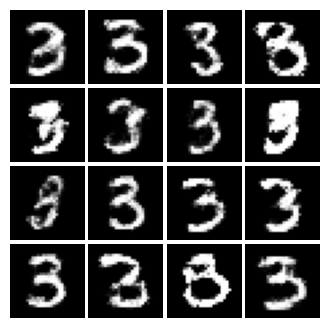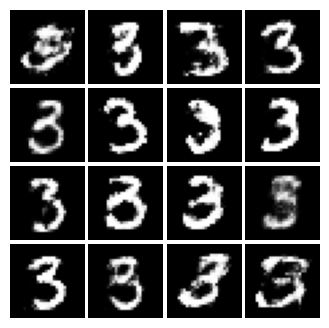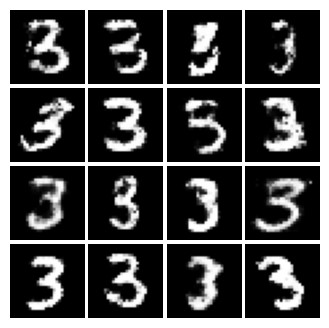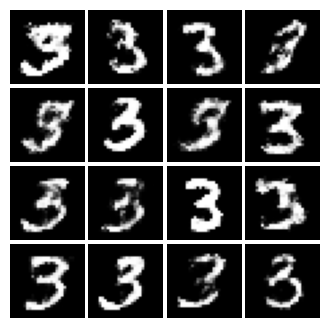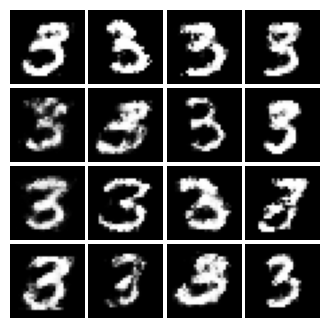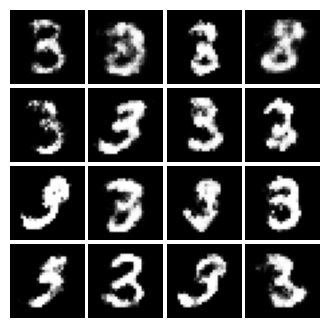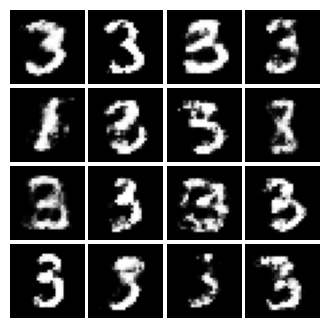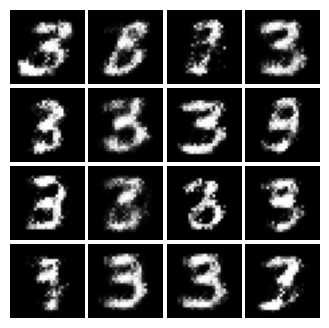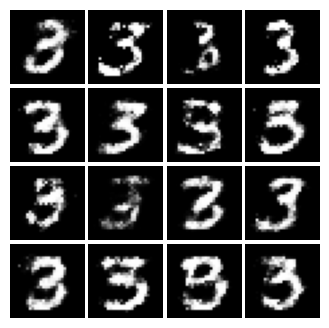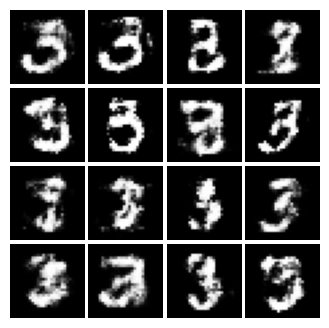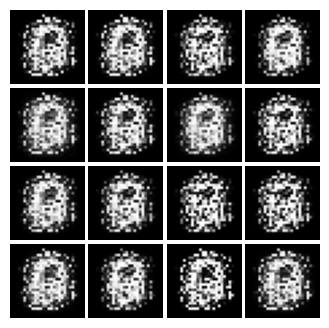

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb

# Hyperparameters
mb_size = 64
Z_dim = 100
y_dim = 10           # Labels: Number of classes (0-9)
h_dim = 128
lr = 1e-3

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Conditional Generator
class Generator(nn.Module):
    def __init__(self, z_dim, y_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim + y_dim, h_dim) # Input is noise + class label
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z, c):  # z is the input noise vector, c is the class label
        x = torch.cat([z, c], dim=1) # Concatenate noise and class label
        h = F.relu(self.fc1(x)) # Hidden layer with ReLU activation
        out = torch.sigmoid(self.fc2(h)) # Output generated image using sigmoid activation
        return out

# Conditional Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, y_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim + y_dim, h_dim)  # Input is image + class label
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, c): # x is the input image, c is the class label
        x = torch.cat([x, c], dim=1) # Concatenate image and class label
        h = F.relu(self.fc1(x)) # Hidden layer with ReLU activation
        out = torch.sigmoid(self.fc2(h)) # Output probability of the input image being real
        return out

# Training Function
def cGANTraining(G, D, loss_fn, train_loader):
    G.train()
    D.train()
    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        # Prepare real data
        X_real = X_real.float().to(device)
        labels = F.one_hot(labels, num_classes=y_dim).float().to(device) # use one-hot encoded labels

        # Sample noise
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)

        # ==== Train Discriminator ====
        G_sample = G(z, labels)
        D_real = D(X_real, labels)
        D_fake = D(G_sample.detach(), labels)

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ==== Train Generator ====
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z, labels)
        D_fake = D(G_sample, labels)

        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

    # Logging
    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    wandb.log({
        "D_loss_real": D_loss_real_avg,
        "D_loss_fake": D_loss_fake_avg,
        "D_loss": D_loss_avg,
        "G_loss": G_loss_avg
    })

    return G, D, G_loss_avg, D_loss_avg

# Save image samples
def save_sample(G, epoch, mb_size, Z_dim, label):
    out_dir = "out_cGAN"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        labels = torch.full((mb_size,), label, dtype=torch.long).to(device)
        labels_one_hot = F.one_hot(labels, num_classes=y_dim).float().to(device) # Choose label to generate
        samples = G(z, labels_one_hot).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(f'{out_dir}'):
        os.makedirs(f'{out_dir}')

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)

###################### Main ########################
wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Models
G = Generator(Z_dim, y_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, y_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Loss Function (BCE with logits version is often better)
def loss_fn(preds, targets):
    return F.binary_cross_entropy(preds, targets)

if wandb_log:
    wandb.init(project="cgan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "y_dim": y_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')
save_dir = 'checkpoints_cgan'
os.makedirs(save_dir, exist_ok=True)

# Training loop
epochs = 100
target_label = 7  # <-- change this number to generate different digits

for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, loss_fn, train_loader)

    print(f'epoch {epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim, target_label)


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 437kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.02MB/s]


D_loss,▁▁▃▅▆▇▇█████████████████████████████████
D_loss_fake,▁▁▂▂▄▆▇▇███████████████████████▇▇▇▇▇▇▇▇▇
D_loss_real,▁▁▂▇▇███████████████████████████████████
G_loss,█▇▇▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D_loss,0.864
D_loss_fake,0.4007
D_loss_real,0.4633
G_loss,1.66079


100%|██████████| 938/938 [00:21<00:00, 43.33it/s]


epoch 0; D_loss: 0.0617; G_loss: 6.6824
Saved Best Models at epoch 0 | G_loss: 6.6824


100%|██████████| 938/938 [00:23<00:00, 39.74it/s]


...

epoch 97; D_loss: 0.8383; G_loss: 1.6897


100%|██████████| 938/938 [00:22<00:00, 42.00it/s]


epoch 98; D_loss: 0.8377; G_loss: 1.6882


100%|██████████| 938/938 [00:22<00:00, 41.05it/s]


epoch 99; D_loss: 0.8367; G_loss: 1.6971


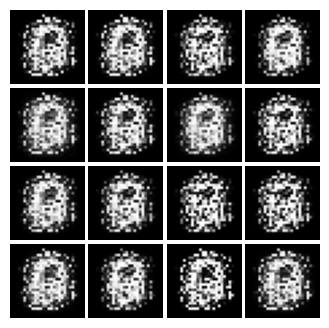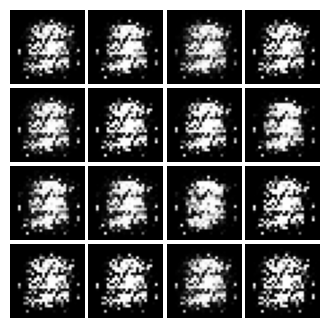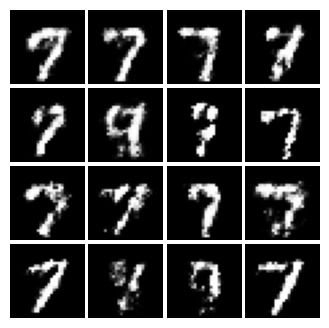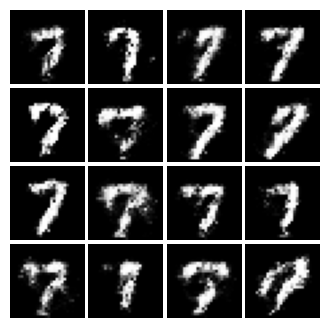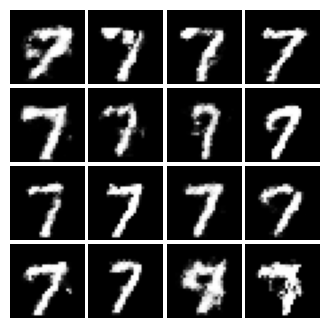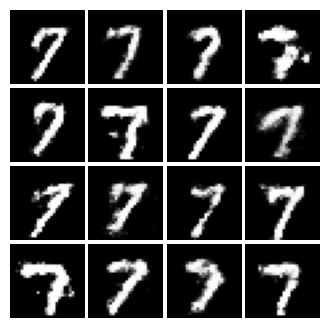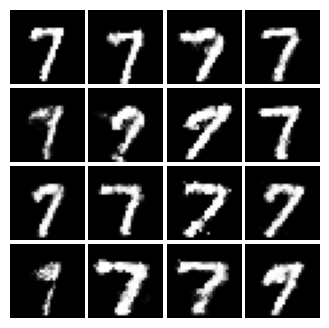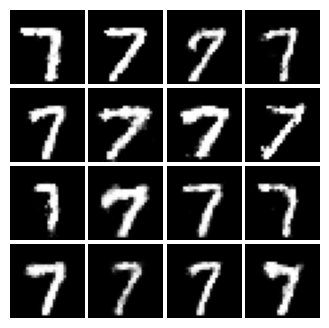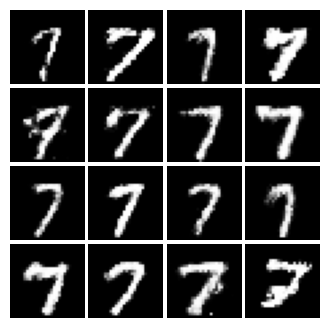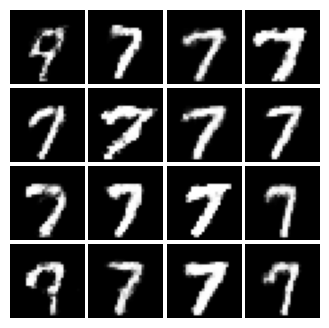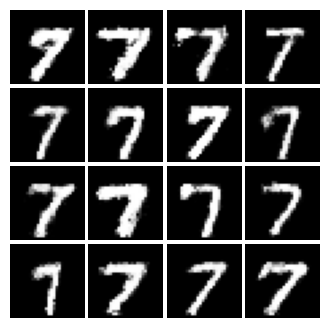